In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [22]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.metrics import structural_similarity as ssim
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import kagglehub

# =========================================================
# DEVICE
# =========================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

# =========================================================
# DOWNLOAD DATASET
# =========================================================

path = kagglehub.dataset_download(
    "indk214/brain-tumor-dataset-segmentation-and-classification"
)

DATA_PATH = os.path.join(
    path,
    "DATASET",
    "Segmentation",
    "Glioma"
)

# =========================================================
# PARAMETERS
# =========================================================

IMG_SIZE = 128
BATCH_SIZE = 4
EPOCHS = 30

Device: cuda


In [23]:

def load_data(folder):

    images = []
    masks = []

    for f in sorted(os.listdir(folder)):

        if "_mask" not in f:

            img_path = os.path.join(folder, f)

            mask_path = os.path.join(
                folder,
                f.replace(".png", "_mask.png")
            )

            if not os.path.exists(mask_path):
                continue

            # IMAGE
            img = cv2.imread(img_path)

            img = cv2.cvtColor(
                img,
                cv2.COLOR_BGR2RGB
            )

            img = cv2.resize(
                img,
                (IMG_SIZE, IMG_SIZE)
            )

            img = img / 255.0

            # MASK
            mask = cv2.imread(mask_path, 0)

            mask = cv2.resize(
                mask,
                (IMG_SIZE, IMG_SIZE)
            )

            mask = (mask > 127).astype(np.float32)

            images.append(img)
            masks.append(mask)

    images = np.array(images, dtype=np.float32)

    masks = np.array(masks, dtype=np.float32)

    return images, masks

X, y = load_data(DATA_PATH)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

# =========================================================
# DATASET CLASS
# =========================================================

class BrainDataset(Dataset):

    def __init__(self, images, masks):

        self.images = images
        self.masks = masks

    def __len__(self):

        return len(self.images)

    def __getitem__(self, idx):

        image = torch.tensor(
            self.images[idx]
        ).permute(2,0,1)

        mask = torch.tensor(
            self.masks[idx]
        ).unsqueeze(0)

        return image.float(), mask.float()

train_dataset = BrainDataset(
    X_train,
    y_train
)

test_dataset = BrainDataset(
    X_test,
    y_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False
)


Train: (443, 128, 128, 3)
Test : (111, 128, 128, 3)


In [25]:
import torch
import torch.nn as nn

# =========================================================
# CONVOLUTION BLOCK
# =========================================================

class ConvBlock(nn.Module):

    def __init__(self, in_channels, out_channels):
        super(ConvBlock, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)

# =========================================================
# ENCODER BLOCK
# =========================================================

class EncoderBlock(nn.Module):

    def __init__(self, in_channels, out_channels):
        super(EncoderBlock, self).__init__()

        self.conv = ConvBlock(
            in_channels,
            out_channels
        )

        self.pool = nn.MaxPool2d(2)

        self.dropout = nn.Dropout2d(0.2)

    def forward(self, x):

        c = self.conv(x)

        p = self.pool(c)

        p = self.dropout(p)

        return c, p

# =========================================================
# DECODER BLOCK
# =========================================================

class DecoderBlock(nn.Module):

    def __init__(self, in_channels, out_channels):
        super(DecoderBlock, self).__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.dropout = nn.Dropout2d(0.2)

        self.conv = ConvBlock(
            out_channels * 2,
            out_channels
        )

    def forward(self, x, skip):

        x = self.up(x)

        x = torch.cat(
            [x, skip],
            dim=1
        )

        x = self.dropout(x)

        x = self.conv(x)

        return x

# =========================================================
# U-NET MODEL
# =========================================================

class UNet(nn.Module):

    def __init__(self):
        super(UNet, self).__init__()

        # Encoder
        self.e1 = EncoderBlock(3, 32)

        self.e2 = EncoderBlock(32, 64)

        self.e3 = EncoderBlock(64, 128)

        # Bottleneck
        self.b1 = ConvBlock(128, 256)

        # Decoder
        self.d1 = DecoderBlock(256, 128)

        self.d2 = DecoderBlock(128, 64)

        self.d3 = DecoderBlock(64, 32)

        # Output
        self.outputs = nn.Conv2d(
            32,
            1,
            kernel_size=1
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        # Encoder
        s1, p1 = self.e1(x)

        s2, p2 = self.e2(p1)

        s3, p3 = self.e3(p2)

        # Bottleneck
        b1 = self.b1(p3)

        # Decoder
        d1 = self.d1(b1, s3)

        d2 = self.d2(d1, s2)

        d3 = self.d3(d2, s1)

        # Output
        outputs = self.outputs(d3)

        outputs = self.sigmoid(outputs)

        return outputs

# =========================================================
# CREATE MODEL
# =========================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = UNet().to(device)

print(model)

UNet(
  (e1): EncoderBlock(
    (conv): ConvBlock(
      (conv): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (dropout): Dropout2d(p=0.2, inplace=False)
  )
  (e2): EncoderBlock(
    (conv): ConvBlock(
      (conv): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4

In [26]:

def dice_coef(y_true, y_pred, smooth=1e-6):

    y_true = y_true.view(-1)

    y_pred = y_pred.view(-1)

    intersection = (
        y_true * y_pred
    ).sum()

    return (
        2. * intersection + smooth
    ) / (
        y_true.sum() +
        y_pred.sum() +
        smooth
    )

def iou_score(y_true, y_pred, smooth=1e-6):

    y_true = y_true.view(-1)

    y_pred = y_pred.view(-1)

    intersection = (
        y_true * y_pred
    ).sum()

    union = (
        y_true.sum() +
        y_pred.sum() -
        intersection
    )

    return (
        intersection + smooth
    ) / (
        union + smooth
    )


In [27]:
# =========================================================
# IMPORTS
# =========================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# =========================================================
# DEVICE
# =========================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# =========================================================
# MODEL TO DEVICE
# =========================================================

model = model.to(device)

# =========================================================
# LOSS FUNCTION
# =========================================================

class DiceBCELoss(nn.Module):

    def __init__(self):
        super(DiceBCELoss, self).__init__()

    def forward(
        self,
        inputs,
        targets,
        smooth=1e-6
    ):

        # BCE LOSS
        bce = F.binary_cross_entropy(
            inputs,
            targets
        )

        # FLATTEN
        inputs = inputs.view(-1)
        targets = targets.view(-1)

        # DICE
        intersection = (
            inputs * targets
        ).sum()

        dice = (
            2. * intersection + smooth
        ) / (
            inputs.sum() +
            targets.sum() +
            smooth
        )

        dice_loss = 1 - dice

        # TOTAL LOSS
        return bce + dice_loss

criterion = DiceBCELoss()

# =========================================================
# OPTIMIZER
# =========================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

# =========================================================
# HISTORY
# =========================================================

history = {
    "train_loss": [],
    "val_loss": [],
    "train_dice": [],
    "val_dice": [],
    "train_iou": [],
    "val_iou": []
}

# =========================================================
# VALIDATION SPLIT
# =========================================================

X_train_new, X_val, y_train_new, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=42
)

# =========================================================
# DATASETS
# =========================================================

train_dataset = BrainDataset(
    X_train_new,
    y_train_new
)

val_dataset = BrainDataset(
    X_val,
    y_val
)

# =========================================================
# DATALOADERS
# =========================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False
)

# =========================================================
# TRAINING LOOP
# =========================================================

for epoch in range(EPOCHS):

    # =====================================================
    # TRAIN MODE
    # =====================================================

    model.train()

    train_loss = 0
    train_dice = 0
    train_iou = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        # ZERO GRADIENTS
        optimizer.zero_grad()

        # FORWARD
        outputs = model(images)

        # LOSS
        loss = criterion(
            outputs,
            masks
        )

        # BACKPROP
        loss.backward()

        # UPDATE
        optimizer.step()

        # PREDICTIONS
        preds = (
            outputs > 0.3
        ).float()

        # METRICS
        train_loss += loss.item()

        train_dice += dice_coef(
            masks,
            preds
        ).item()

        train_iou += iou_score(
            masks,
            preds
        ).item()

    # =====================================================
    # AVERAGE TRAIN METRICS
    # =====================================================

    avg_train_loss = train_loss / len(train_loader)

    avg_train_dice = train_dice / len(train_loader)

    avg_train_iou = train_iou / len(train_loader)

    # =====================================================
    # VALIDATION MODE
    # =====================================================

    model.eval()

    val_loss = 0
    val_dice = 0
    val_iou = 0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            # FORWARD
            outputs = model(images)

            # LOSS
            loss = criterion(
                outputs,
                masks
            )

            # PREDICTIONS
            preds = (
                outputs > 0.3
            ).float()

            # METRICS
            val_loss += loss.item()

            val_dice += dice_coef(
                masks,
                preds
            ).item()

            val_iou += iou_score(
                masks,
                preds
            ).item()

    # =====================================================
    # AVERAGE VALIDATION METRICS
    # =====================================================

    avg_val_loss = val_loss / len(val_loader)

    avg_val_dice = val_dice / len(val_loader)

    avg_val_iou = val_iou / len(val_loader)

    # =====================================================
    # STORE HISTORY
    # =====================================================

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)

    history["train_dice"].append(avg_train_dice)
    history["val_dice"].append(avg_val_dice)

    history["train_iou"].append(avg_train_iou)
    history["val_iou"].append(avg_val_iou)

    # =====================================================
    # PRINT RESULTS
    # =====================================================

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Train Dice: {avg_train_dice:.4f} | "
        f"Val Dice: {avg_val_dice:.4f} | "
        f"Train IoU: {avg_train_iou:.4f} | "
        f"Val IoU: {avg_val_iou:.4f}"
    )

Epoch [1/30] | Train Loss: 1.5328 | Val Loss: 1.4671 | Train Dice: 0.0367 | Val Dice: 0.0363 | Train IoU: 0.0188 | Val IoU: 0.0186
Epoch [2/30] | Train Loss: 1.4044 | Val Loss: 1.3739 | Train Dice: 0.0347 | Val Dice: 0.0384 | Train IoU: 0.0177 | Val IoU: 0.0197
Epoch [3/30] | Train Loss: 1.3446 | Val Loss: 1.3267 | Train Dice: 0.0444 | Val Dice: 0.0412 | Train IoU: 0.0229 | Val IoU: 0.0212
Epoch [4/30] | Train Loss: 1.2955 | Val Loss: 1.2971 | Train Dice: 0.0923 | Val Dice: 0.1362 | Train IoU: 0.0494 | Val IoU: 0.0754
Epoch [5/30] | Train Loss: 1.2415 | Val Loss: 1.2181 | Train Dice: 0.2035 | Val Dice: 0.3000 | Train IoU: 0.1166 | Val IoU: 0.1921
Epoch [6/30] | Train Loss: 1.1942 | Val Loss: 1.1799 | Train Dice: 0.3355 | Val Dice: 0.3425 | Train IoU: 0.2082 | Val IoU: 0.2225
Epoch [7/30] | Train Loss: 1.1524 | Val Loss: 1.1327 | Train Dice: 0.3925 | Val Dice: 0.4144 | Train IoU: 0.2512 | Val IoU: 0.2909
Epoch [8/30] | Train Loss: 1.1134 | Val Loss: 1.0889 | Train Dice: 0.4150 | Val Dic

In [28]:
# =========================================================
# EVALUATION
# =========================================================

model.eval()

dice_scores = []

iou_scores = []

preds_bin = []

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)

        masks = masks.to(device)

        outputs = model(images)

        preds = (
            outputs > 0.3
        ).float()

        preds_bin.append(
            preds.cpu().numpy()
        )

        dice_scores.append(
            dice_coef(
                masks,
                preds
            ).item()
        )

        iou_scores.append(
            iou_score(
                masks,
                preds
            ).item()
        )

dice_clean = np.mean(dice_scores)

iou_clean = np.mean(iou_scores)

print("\n===== CLEAN RESULTS =====")

print("Dice :", dice_clean)

print("IoU  :", iou_clean)


===== CLEAN RESULTS =====
Dice : 0.6229103439639936
IoU  : 0.5230946808794716


In [29]:
# =========================================================
# FGSM ATTACK
# =========================================================

def fgsm_attack(
    model,
    images,
    masks,
    epsilon=0.03
):

    images.requires_grad = True

    outputs = model(images)

    loss = criterion(
        outputs,
        masks
    )

    model.zero_grad()

    loss.backward()

    data_grad = images.grad.data

    adv_images = (
        images +
        epsilon * data_grad.sign()
    )

    adv_images = torch.clamp(
        adv_images,
        0,
        1
    )

    return adv_images

# =========================================================
# PGD ATTACK
# =========================================================

def pgd_attack(
    model,
    images,
    masks,
    epsilon=0.03,
    alpha=0.005,
    iterations=10
):

    ori_images = images.data

    for i in range(iterations):

        images.requires_grad = True

        outputs = model(images)

        loss = criterion(
            outputs,
            masks
        )

        model.zero_grad()

        loss.backward()

        adv_images = (
            images +
            alpha * images.grad.sign()
        )

        eta = torch.clamp(
            adv_images - ori_images,
            min=-epsilon,
            max=epsilon
        )

        images = torch.clamp(
            ori_images + eta,
            min=0,
            max=1
        ).detach()

    return images


In [30]:
# =========================================================
# FGSM + PGD EVALUATION
# =========================================================

fgsm_dice = []

fgsm_iou = []

pgd_dice = []

pgd_iou = []

X_test_fgsm = []

X_test_pgd = []

preds_fgsm = []

preds_pgd = []

for images, masks in test_loader:

    images = images.to(device)

    masks = masks.to(device)

    # FGSM
    fgsm_images = fgsm_attack(
        model,
        images.clone(),
        masks
    )

    fgsm_outputs = model(
        fgsm_images
    )

    fgsm_preds = (
        fgsm_outputs > 0.3
    ).float()

    X_test_fgsm.append(
        fgsm_images.squeeze().permute(1,2,0).detach().cpu().numpy()
    )

    preds_fgsm.append(
        fgsm_preds.squeeze().detach().cpu().numpy()
    )

    fgsm_dice.append(
        dice_coef(
            masks,
            fgsm_preds
        ).item()
    )

    fgsm_iou.append(
        iou_score(
            masks,
            fgsm_preds
        ).item()
    )

    # PGD
    pgd_images = pgd_attack(
        model,
        images.clone(),
        masks
    )

    pgd_outputs = model(
        pgd_images
    )

    pgd_preds = (
        pgd_outputs > 0.3
    ).float()

    X_test_pgd.append(
        pgd_images.squeeze().permute(1,2,0).detach().cpu().numpy()
    )

    preds_pgd.append(
        pgd_preds.squeeze().detach().cpu().numpy()
    )

    pgd_dice.append(
        dice_coef(
            masks,
            pgd_preds
        ).item()
    )

    pgd_iou.append(
        iou_score(
            masks,
            pgd_preds
        ).item()
    )

dice_fgsm = np.mean(fgsm_dice)

iou_fgsm = np.mean(fgsm_iou)

dice_pgd = np.mean(pgd_dice)

iou_pgd = np.mean(pgd_iou)

print("\n===== FGSM RESULTS =====")

print("Dice :", dice_fgsm)

print("IoU  :", iou_fgsm)

print("\n===== PGD RESULTS =====")

print("Dice :", dice_pgd)

print("IoU  :", iou_pgd)


===== FGSM RESULTS =====
Dice : 0.28222793687803976
IoU  : 0.19761252800826912

===== PGD RESULTS =====
Dice : 0.13881778144591397
IoU  : 0.08504798753597316


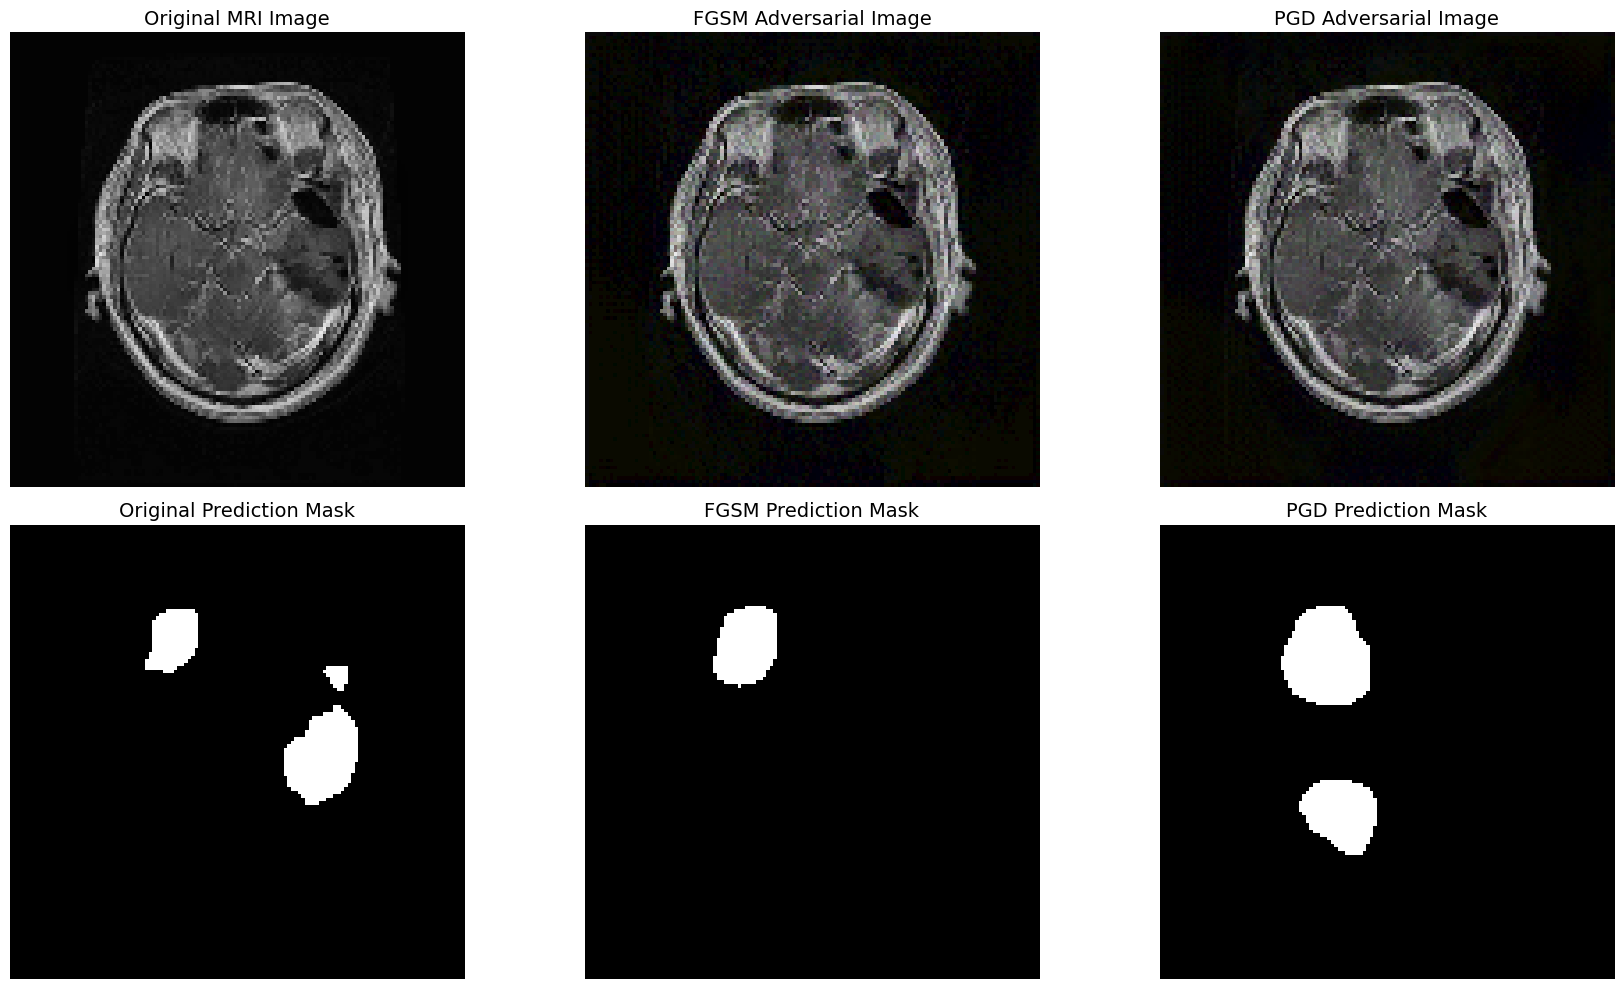

In [31]:
# =========================================================
#  U-NET VISUALIZATION
# 6 Proper Ordered Images
#
# 1. Original MRI Image
# 2. FGSM Adversarial Image
# 3. PGD Adversarial Image
# 4. Original Prediction Mask
# 5. FGSM Prediction Mask
# 6. PGD Prediction Mask
# =========================================================

import matplotlib.pyplot as plt
import numpy as np
import torch

# =========================================================
# SELECT SAMPLE
# =========================================================

idx = 8

# =========================================================
# GET ORIGINAL IMAGE
# =========================================================

original_img = X_test[idx]

# =========================================================
# CONVERT IMAGE TO TENSOR
# =========================================================

image_tensor = torch.tensor(
    original_img
).permute(2,0,1).unsqueeze(0).float().to(device)

mask_tensor = torch.tensor(
    y_test[idx]
).unsqueeze(0).unsqueeze(0).float().to(device)

# =========================================================
# GENERATE FGSM + PGD IMAGES
# =========================================================

fgsm_image = fgsm_attack(
    model,
    image_tensor.clone(),
    mask_tensor
)

pgd_image = pgd_attack(
    model,
    image_tensor.clone(),
    mask_tensor
)

# =========================================================
# CONVERT TO NUMPY
# =========================================================

fgsm_adv = fgsm_image.squeeze(0).permute(1,2,0).detach().cpu().numpy()

pgd_adv = pgd_image.squeeze(0).permute(1,2,0).detach().cpu().numpy()

# =========================================================
# PREDICTIONS
# =========================================================

model.eval()

with torch.no_grad():

    # CLEAN
    clean_output = model(image_tensor)

    clean_pred = (
        clean_output > 0.3
    ).float()

    clean_pred = clean_pred.squeeze().cpu().numpy()

    # FGSM
    fgsm_output = model(fgsm_image)

    fgsm_pred = (
        fgsm_output > 0.3
    ).float()

    fgsm_pred = fgsm_pred.squeeze().cpu().numpy()

    # PGD
    pgd_output = model(pgd_image)

    pgd_pred = (
        pgd_output > 0.3
    ).float()

    pgd_pred = pgd_pred.squeeze().cpu().numpy()

# =========================================================
# VISUALIZATION
# =========================================================

plt.figure(figsize=(18,10))

# =========================================================
# ROW 1 : IMAGES
# =========================================================

# ORIGINAL MRI IMAGE
plt.subplot(2,3,1)

plt.imshow(original_img)

plt.title(
    "Original MRI Image",
    fontsize=14
)

plt.axis("off")

# FGSM ADVERSARIAL IMAGE
plt.subplot(2,3,2)

plt.imshow(fgsm_adv)

plt.title(
    "FGSM Adversarial Image",
    fontsize=14
)

plt.axis("off")

# PGD ADVERSARIAL IMAGE
plt.subplot(2,3,3)

plt.imshow(pgd_adv)

plt.title(
    "PGD Adversarial Image",
    fontsize=14
)

plt.axis("off")

# =========================================================
# ROW 2 : PREDICTION MASKS
# =========================================================

# CLEAN PREDICTION
plt.subplot(2,3,4)

plt.imshow(
    clean_pred,
    cmap="gray"
)

plt.title(
    "Original Prediction Mask",
    fontsize=14
)

plt.axis("off")

# FGSM PREDICTION
plt.subplot(2,3,5)

plt.imshow(
    fgsm_pred,
    cmap="gray"
)

plt.title(
    "FGSM Prediction Mask",
    fontsize=14
)

plt.axis("off")

# PGD PREDICTION
plt.subplot(2,3,6)

plt.imshow(
    pgd_pred,
    cmap="gray"
)

plt.title(
    "PGD Prediction Mask",
    fontsize=14
)

plt.axis("off")

# =========================================================
# SHOW
# =========================================================

plt.tight_layout()

plt.show()

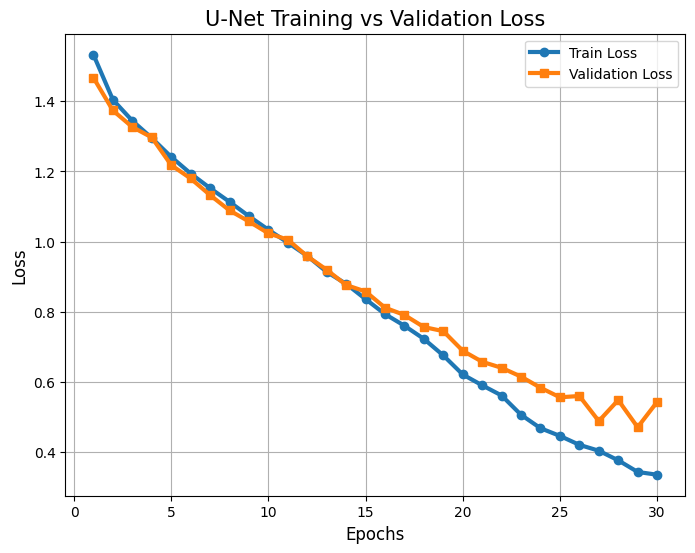

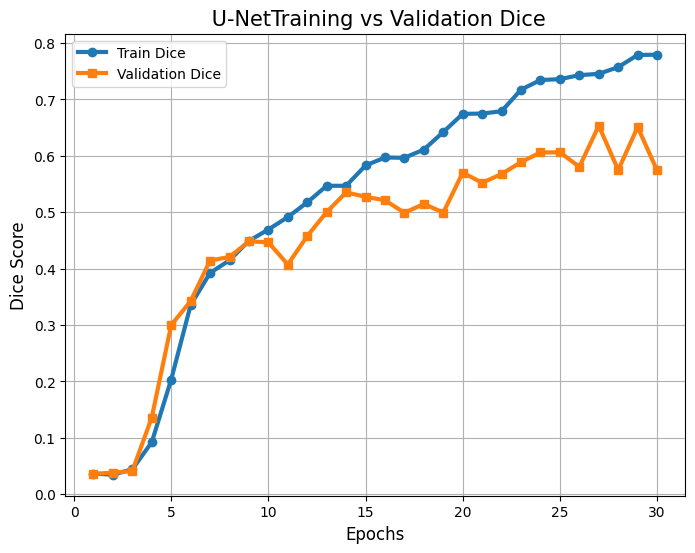

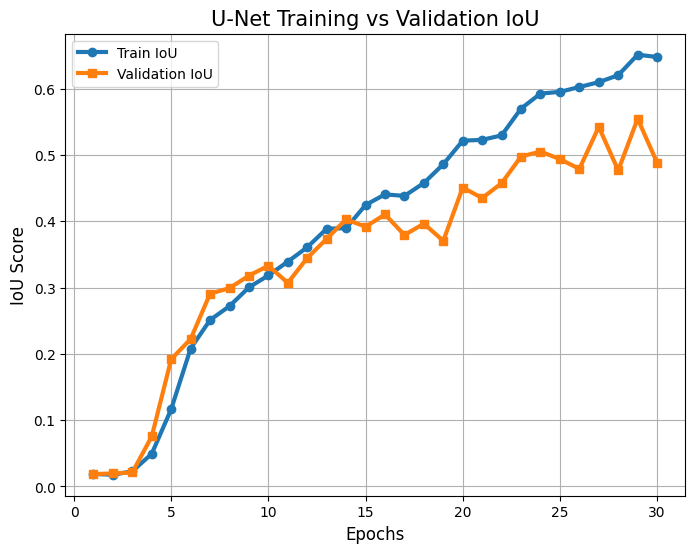

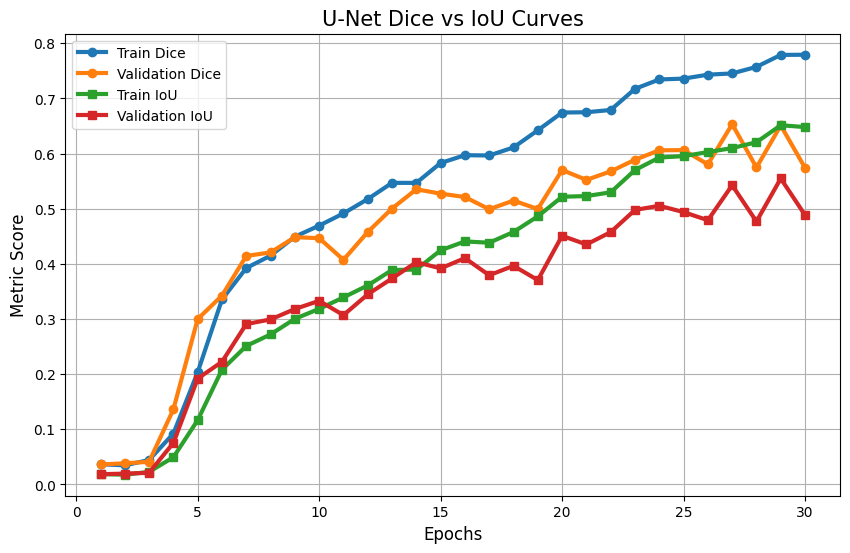

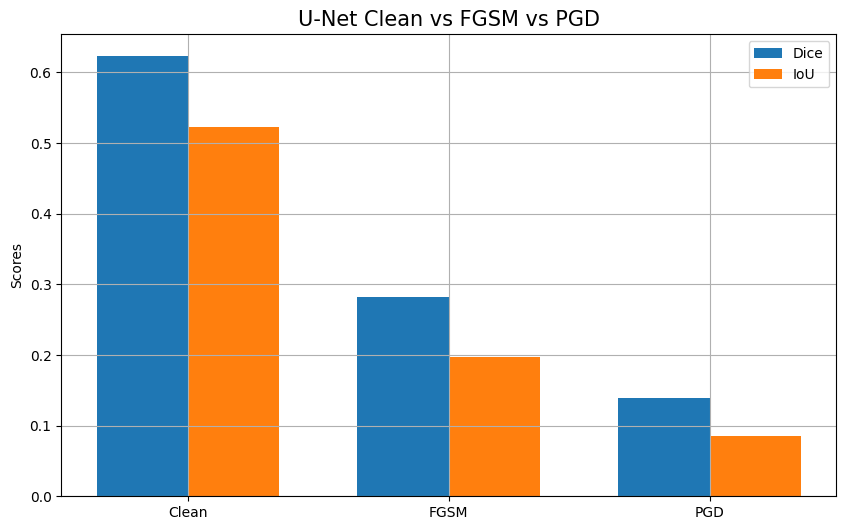

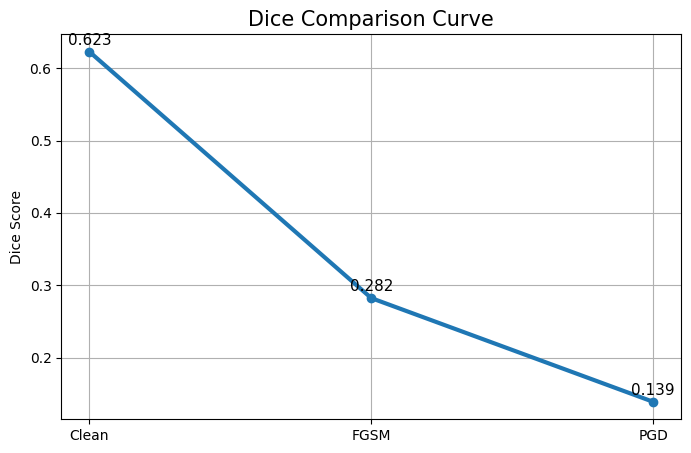

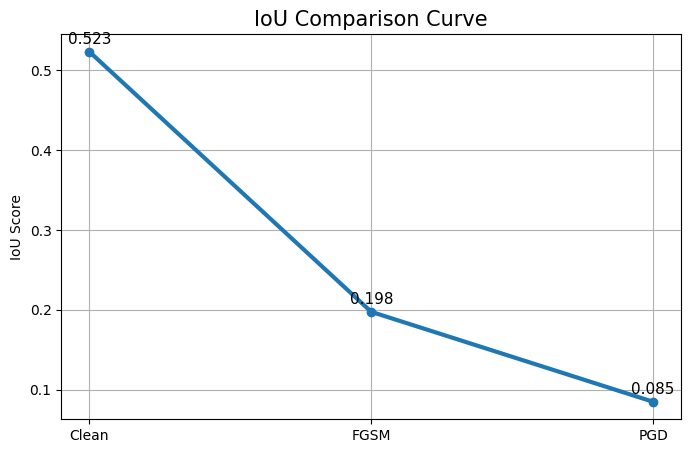

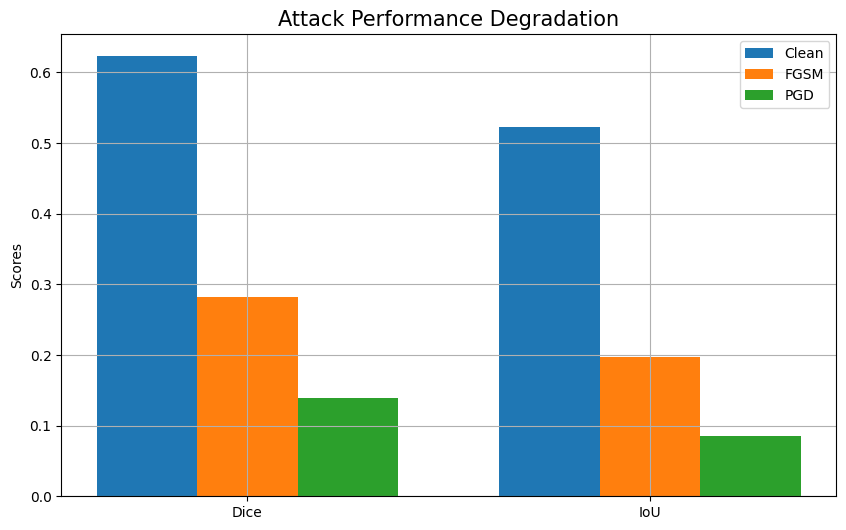


================ FINAL RESULTS ================

CLEAN IMAGES
Dice : 0.6229
IoU  : 0.5231

FGSM ATTACK
Dice : 0.2822
IoU  : 0.1976

PGD ATTACK
Dice : 0.1388
IoU  : 0.0850


In [32]:
# =========================================================
# COMPLETE EVALUATION CURVES WITH VALIDATION
#  U-Net
# =========================================================

import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# HISTORY VALUES
# =========================================================

train_loss = history["train_loss"]

val_loss = history["val_loss"]

train_dice = history["train_dice"]

val_dice = history["val_dice"]

train_iou = history["train_iou"]

val_iou = history["val_iou"]

epochs_range = range(1, len(train_loss) + 1)

# =========================================================
# 1. TRAINING vs VALIDATION LOSS CURVE
# =========================================================

plt.figure(figsize=(8,6))

plt.plot(
    epochs_range,
    train_loss,
    marker='o',
    linewidth=3,
    label='Train Loss'
)

plt.plot(
    epochs_range,
    val_loss,
    marker='s',
    linewidth=3,
    label='Validation Loss'
)

plt.xlabel("Epochs", fontsize=12)

plt.ylabel("Loss", fontsize=12)

plt.title(
    "U-Net Training vs Validation Loss",
    fontsize=15
)

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# 2. TRAINING vs VALIDATION DICE CURVE
# =========================================================

plt.figure(figsize=(8,6))

plt.plot(
    epochs_range,
    train_dice,
    marker='o',
    linewidth=3,
    label='Train Dice'
)

plt.plot(
    epochs_range,
    val_dice,
    marker='s',
    linewidth=3,
    label='Validation Dice'
)

plt.xlabel("Epochs", fontsize=12)

plt.ylabel("Dice Score", fontsize=12)

plt.title(
    " U-NetTraining vs Validation Dice",
    fontsize=15
)

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# 3. TRAINING vs VALIDATION IOU CURVE
# =========================================================

plt.figure(figsize=(8,6))

plt.plot(
    epochs_range,
    train_iou,
    marker='o',
    linewidth=3,
    label='Train IoU'
)

plt.plot(
    epochs_range,
    val_iou,
    marker='s',
    linewidth=3,
    label='Validation IoU'
)

plt.xlabel("Epochs", fontsize=12)

plt.ylabel("IoU Score", fontsize=12)

plt.title(
    "U-Net Training vs Validation IoU",
    fontsize=15
)

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# 4. DICE + IOU COMBINED CURVE
# =========================================================

plt.figure(figsize=(10,6))

plt.plot(
    epochs_range,
    train_dice,
    marker='o',
    linewidth=3,
    label='Train Dice'
)

plt.plot(
    epochs_range,
    val_dice,
    marker='o',
    linewidth=3,
    label='Validation Dice'
)

plt.plot(
    epochs_range,
    train_iou,
    marker='s',
    linewidth=3,
    label='Train IoU'
)

plt.plot(
    epochs_range,
    val_iou,
    marker='s',
    linewidth=3,
    label='Validation IoU'
)

plt.xlabel("Epochs", fontsize=12)

plt.ylabel("Metric Score", fontsize=12)

plt.title(
    "U-Net Dice vs IoU Curves",
    fontsize=15
)

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# 5. CLEAN vs FGSM vs PGD BAR GRAPH
# =========================================================

methods = ['Clean', 'FGSM', 'PGD']

dice_values = [
    dice_clean,
    dice_fgsm,
    dice_pgd
]

iou_values = [
    iou_clean,
    iou_fgsm,
    iou_pgd
]

x = np.arange(len(methods))

width = 0.35

plt.figure(figsize=(10,6))

plt.bar(
    x - width/2,
    dice_values,
    width,
    label='Dice'
)

plt.bar(
    x + width/2,
    iou_values,
    width,
    label='IoU'
)

plt.xticks(x, methods)

plt.ylabel("Scores")

plt.title(
    "U-Net Clean vs FGSM vs PGD",
    fontsize=15
)

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# 6. DICE COMPARISON CURVE
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(
    methods,
    dice_values,
    marker='o',
    linewidth=3
)

for i, v in enumerate(dice_values):

    plt.text(
        i,
        v + 0.01,
        f"{v:.3f}",
        ha='center',
        fontsize=11
    )

plt.ylabel("Dice Score")

plt.title(
    "Dice Comparison Curve",
    fontsize=15
)

plt.grid(True)

plt.show()

# =========================================================
# 7. IOU COMPARISON CURVE
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(
    methods,
    iou_values,
    marker='o',
    linewidth=3
)

for i, v in enumerate(iou_values):

    plt.text(
        i,
        v + 0.01,
        f"{v:.3f}",
        ha='center',
        fontsize=11
    )

plt.ylabel("IoU Score")

plt.title(
    "IoU Comparison Curve",
    fontsize=15
)

plt.grid(True)

plt.show()

# =========================================================
# 8. ATTACK PERFORMANCE DEGRADATION
# =========================================================

clean_metrics = [
    dice_clean,
    iou_clean
]

fgsm_metrics = [
    dice_fgsm,
    iou_fgsm
]

pgd_metrics = [
    dice_pgd,
    iou_pgd
]

metric_names = ['Dice', 'IoU']

x = np.arange(len(metric_names))

width = 0.25

plt.figure(figsize=(10,6))

plt.bar(
    x - width,
    clean_metrics,
    width,
    label='Clean'
)

plt.bar(
    x,
    fgsm_metrics,
    width,
    label='FGSM'
)

plt.bar(
    x + width,
    pgd_metrics,
    width,
    label='PGD'
)

plt.xticks(x, metric_names)

plt.ylabel("Scores")

plt.title(
    "Attack Performance Degradation",
    fontsize=15
)

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# FINAL RESULTS
# =========================================================

print("\n================ FINAL RESULTS ================\n")

print("CLEAN IMAGES")
print(f"Dice : {dice_clean:.4f}")
print(f"IoU  : {iou_clean:.4f}")

print("\nFGSM ATTACK")
print(f"Dice : {dice_fgsm:.4f}")
print(f"IoU  : {iou_fgsm:.4f}")

print("\nPGD ATTACK")
print(f"Dice : {dice_pgd:.4f}")
print(f"IoU  : {iou_pgd:.4f}")

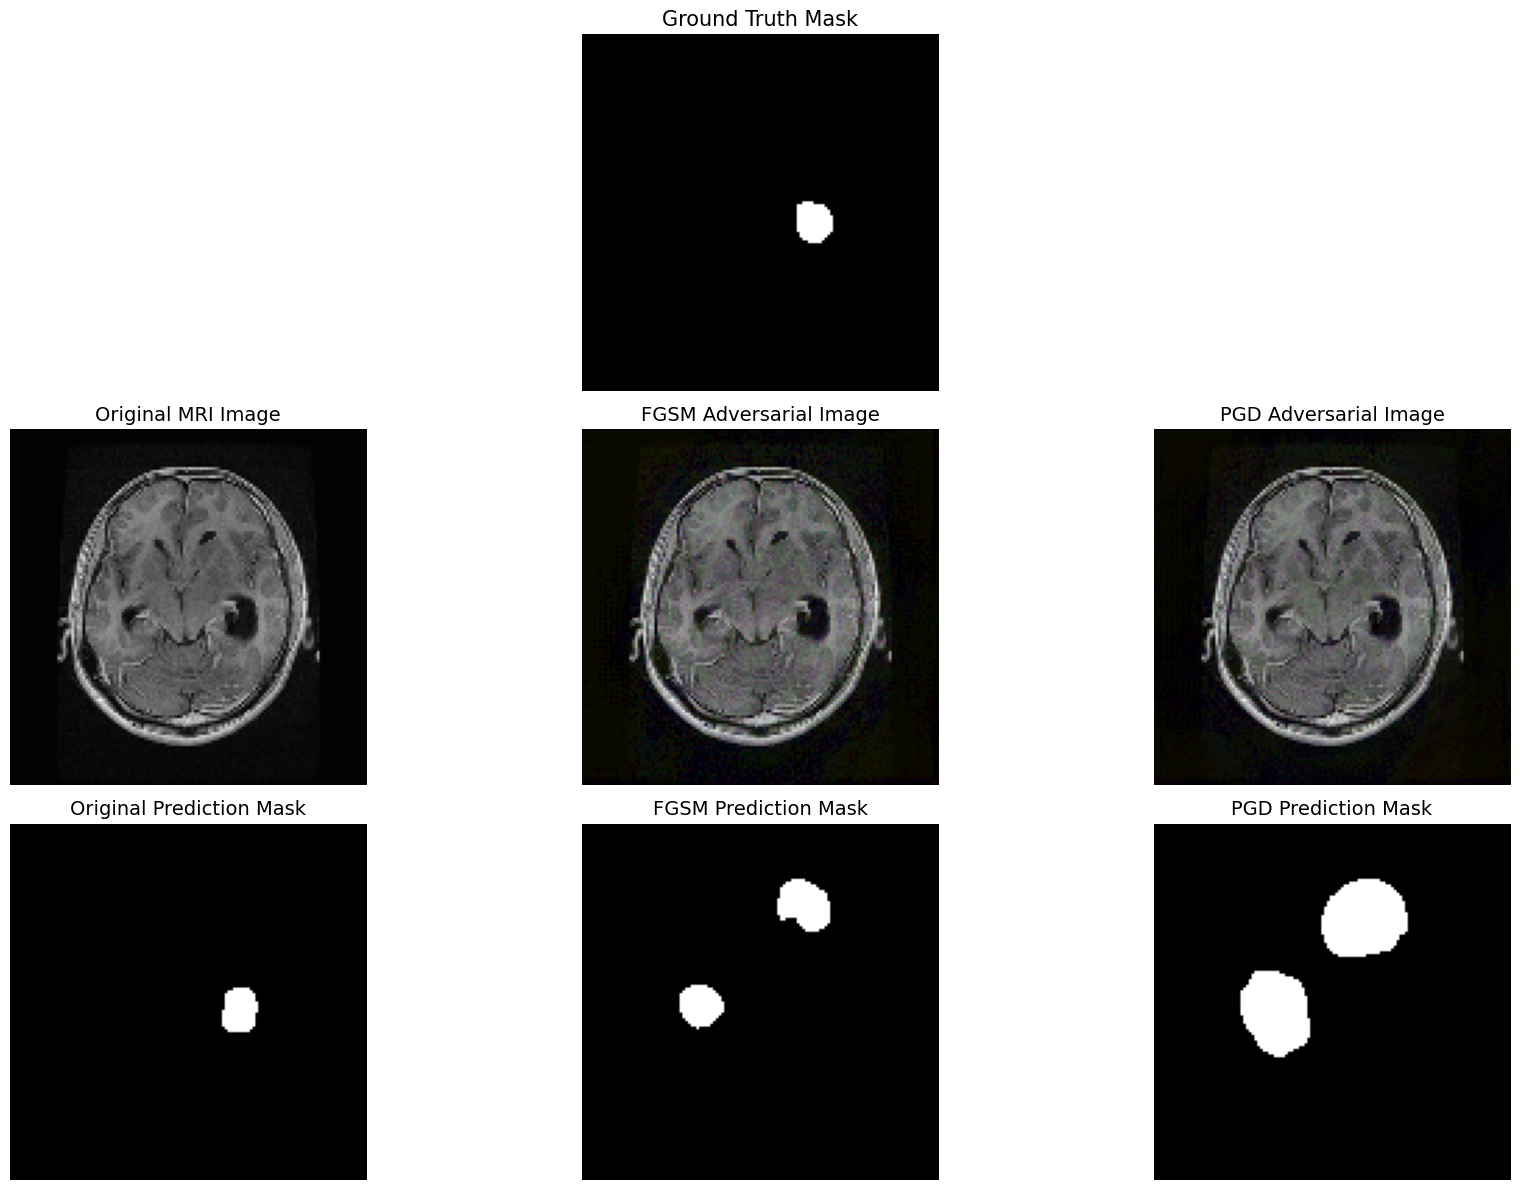

In [33]:
# =========================================================
# VISUALIZATION WITH GROUND TRUTH ABOVE
#
# TOP:
# 1. Ground Truth Mask
#
# ROW 1:
# 2. Original MRI Image
# 3. FGSM Adversarial Image
# 4. PGD Adversarial Image
#
# ROW 2:
# 5. Original Prediction Mask
# 6. FGSM Prediction Mask
# 7. PGD Prediction Mask
# =========================================================

import matplotlib.pyplot as plt
import numpy as np
import torch

# =========================================================
# SELECT SAMPLE
# =========================================================

idx = 44

# =========================================================
# ORIGINAL IMAGE + GROUND TRUTH
# =========================================================

original_img = X_test[idx]

ground_truth = y_test[idx]

# =========================================================
# CONVERT TO TENSOR
# =========================================================

image_tensor = torch.tensor(
    original_img
).permute(2,0,1).unsqueeze(0).float().to(device)

mask_tensor = torch.tensor(
    y_test[idx]
).unsqueeze(0).unsqueeze(0).float().to(device)

# =========================================================
# GENERATE ADVERSARIAL IMAGES
# =========================================================

fgsm_image = fgsm_attack(
    model,
    image_tensor.clone(),
    mask_tensor
)

pgd_image = pgd_attack(
    model,
    image_tensor.clone(),
    mask_tensor
)

# =========================================================
# CONVERT TO NUMPY
# =========================================================

fgsm_adv = fgsm_image.squeeze(0).permute(1,2,0).detach().cpu().numpy()

pgd_adv = pgd_image.squeeze(0).permute(1,2,0).detach().cpu().numpy()

# =========================================================
# PREDICTIONS
# =========================================================

model.eval()

with torch.no_grad():

    # CLEAN
    clean_output = model(image_tensor)

    clean_pred = (
        clean_output > 0.3
    ).float()

    clean_pred = clean_pred.squeeze().cpu().numpy()

    # FGSM
    fgsm_output = model(fgsm_image)

    fgsm_pred = (
        fgsm_output > 0.3
    ).float()

    fgsm_pred = fgsm_pred.squeeze().cpu().numpy()

    # PGD
    pgd_output = model(pgd_image)

    pgd_pred = (
        pgd_output > 0.3
    ).float()

    pgd_pred = pgd_pred.squeeze().cpu().numpy()

# =========================================================
# VISUALIZATION
# =========================================================

fig = plt.figure(figsize=(18,12))

# =========================================================
# TOP GROUND TRUTH
# =========================================================

ax1 = plt.subplot2grid(
    (3,3),
    (0,1)
)

ax1.imshow(
    ground_truth,
    cmap="gray"
)

ax1.set_title(
    "Ground Truth Mask",
    fontsize=15
)

ax1.axis("off")

# =========================================================
# ROW 1 : IMAGES
# =========================================================

# ORIGINAL MRI IMAGE
ax2 = plt.subplot2grid(
    (3,3),
    (1,0)
)

ax2.imshow(original_img)

ax2.set_title(
    "Original MRI Image",
    fontsize=14
)

ax2.axis("off")

# FGSM IMAGE
ax3 = plt.subplot2grid(
    (3,3),
    (1,1)
)

ax3.imshow(fgsm_adv)

ax3.set_title(
    "FGSM Adversarial Image",
    fontsize=14
)

ax3.axis("off")

# PGD IMAGE
ax4 = plt.subplot2grid(
    (3,3),
    (1,2)
)

ax4.imshow(pgd_adv)

ax4.set_title(
    "PGD Adversarial Image",
    fontsize=14
)

ax4.axis("off")

# =========================================================
# ROW 2 : PREDICTIONS
# =========================================================

# CLEAN PREDICTION
ax5 = plt.subplot2grid(
    (3,3),
    (2,0)
)

ax5.imshow(
    clean_pred,
    cmap="gray"
)

ax5.set_title(
    "Original Prediction Mask",
    fontsize=14
)

ax5.axis("off")

# FGSM PREDICTION
ax6 = plt.subplot2grid(
    (3,3),
    (2,1)
)

ax6.imshow(
    fgsm_pred,
    cmap="gray"
)

ax6.set_title(
    "FGSM Prediction Mask",
    fontsize=14
)

ax6.axis("off")

# PGD PREDICTION
ax7 = plt.subplot2grid(
    (3,3),
    (2,2)
)

ax7.imshow(
    pgd_pred,
    cmap="gray"
)

ax7.set_title(
    "PGD Prediction Mask",
    fontsize=14
)

ax7.axis("off")

# =========================================================
# SHOW
# =========================================================

plt.tight_layout()

plt.show()